# Тема 7. Обучение без учителя: PCA и кластеризация

## Практика: сегментация пассажиров «Титаника»

Как и в теории — забудем про `Survived` и попробуем найти естественные группы пассажиров по остальным признакам. Потом, только для проверки, посмотрим, различается ли выживаемость между найденными группами.

Самостоятельная работа. Если не хватает метода — см. `lesson07_unsupervised_theory.ipynb`.

**Это файл с решениями — используйте для самопроверки.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

**1. Подготовка данных** — признаки без `Survived`.

In [2]:
data = pd.read_csv("../data/titanic_train.csv", index_col="PassengerId")
data["Sex"] = (data["Sex"] == "male").astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features]
X_scaled = StandardScaler().fit_transform(X)

**2. Сожмите `X_scaled` в 2D через `PCA(n_components=2)` и постройте scatter, раскрашенный по `data['Survived']` (`c=data['Survived']`, `cmap='coolwarm'`). Видно ли на глаз разделение?**

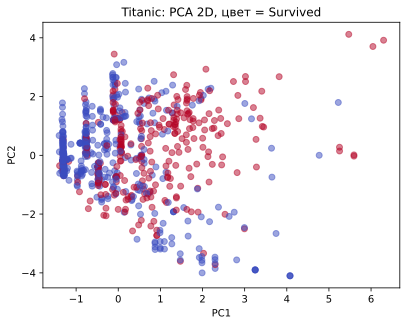

In [3]:
X_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data["Survived"], cmap="coolwarm", alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Titanic: PCA 2D, цвет = Survived");

**3. Выбор `k`.** Для `k` от 2 до 7 обучите `KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)` на `X_scaled` и посчитайте `silhouette_score`. Постройте график.

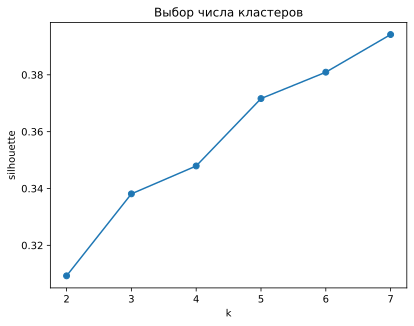

In [4]:
ks = range(2, 8)
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

plt.plot(ks, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.title("Выбор числа кластеров");

**4. Обучите `KMeans` с `k=3` (компромисс между силуэтом и интерпретируемостью — 2 кластера обычно слишком грубо). Для каждого кластера посчитайте средние `Pclass`, `Sex`, `Age`, `Fare` и долю выживших (`Survived`). Опишите словами, что это за 3 типа пассажиров.**

In [5]:
km3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
data["cluster"] = km3.fit_predict(X_scaled)

summary = data.groupby("cluster")[features].mean()
summary["survival_rate"] = data.groupby("cluster")["Survived"].mean()
summary["count"] = data.groupby("cluster").size()
summary

,Pclass,Sex,Age,SibSp,Parch,Fare,survival_rate,count
cluster,,,,,,,,
0,2.783626,0.766082,27.845848,0.208577,0.058480,11.895239,0.253411,513
1,1.147679,0.569620,39.748945,0.350211,0.236287,70.237746,0.594937,237
2,2.531915,0.347518,17.416667,1.957447,1.801418,42.165572,0.503546,141


_Пример описания (сверьтесь после решения задачи 4): один кластер — небогатые пассажиры 3 класса, в основном мужчины, с низкой выживаемостью; другой — обеспеченные пассажиры постарше, выживаемость заметно выше; третий — молодые пассажиры с большими семьями (высокие `SibSp`/`Parch`), тоже 3 класс, средняя выживаемость. Кластеризация нашла что-то похожее на социально-экономические группы, ни разу не взглянув на `Survived`.

---
## Итог

Мы прошли путь от «просто посмотреть на данные» (темы 1-2) через классификацию (темы 3-6) до поиска структуры совсем без разметки (тема 7). Последнее занятие курса — градиентный бустинг, самый сильный из инструментов для нашей исходной задачи оттока.